# Bagian 1 — Banking Transaction Analysis
## CRISP-DM Framework

## 1. Business Understanding

**Problem Statement:**  
The bank wants to better understand its customers by segmenting them based on their transaction behavior. Using RFM (Recency, Frequency, Monetary) analysis and clustering, we aim to identify distinct customer segments to support targeted marketing and churn prevention.

**Business Goals:**
- Identify high-value customers to target with loyalty and premium-product offers
- Detect dormant/at-risk customers for re-engagement campaigns
- Reduce customer churn rate and increase retention

**Success Criteria:**
- Silhouette score ≥ 0.35 (well-separated clusters)
- Clusters must be business-interpretable and actionable
- Each segment should map to at least one concrete marketing action

**Scope:**  
Two transaction datasets are combined — a large domestic (India) dataset and a smaller foreign customer dataset. Both are treated as a unified customer base because they share the same schema and business context (retail banking).

## 2. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import cupy as cp
from numpy import log1p
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from cuml.cluster import KMeans as cuKMeans
from cuml.metrics.cluster import silhouette_score as cu_silhouette_score
from matplotlib.patches import Ellipse

warnings.filterwarnings('ignore')
np.random.seed(42)

print('numpy:', np.__version__)
print('cupy:', cp.__version__)
print('GPU count:', cp.cuda.runtime.getDeviceCount())

numpy: 2.2.6
cupy: 14.0.1
GPU count: 1


In [2]:
# Load datasets
df_india = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv')
df_foreign = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv')

print('India shape:', df_india.shape)
print('Foreign shape:', df_foreign.shape)
df_india.head()

India shape: (1048567, 9)
Foreign shape: (3584, 11)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [3]:
# Data types and missing values
print(df_india.info())
print('\nMissing values (India):')
print(df_india.isnull().sum())
print('\nMissing values (Foreign):')
print(df_foreign.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB
None

Missing values (India):
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance 

In [4]:
df_india.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


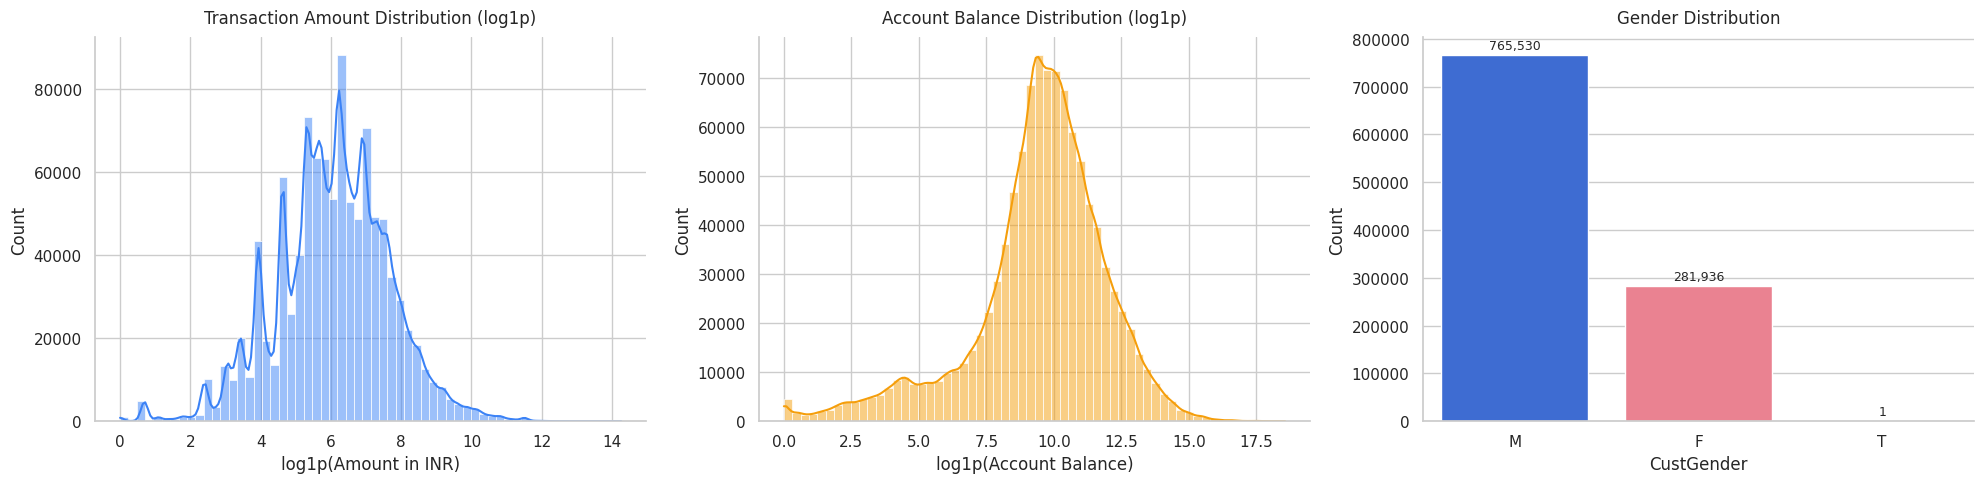

In [5]:
# Key distributions — log-scale for skewed financial data
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

amount_log = np.log1p(df_india['TransactionAmount (INR)'])
sns.histplot(amount_log, bins=60, kde=True, color='#3b82f6', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (log1p)', fontsize=12, pad=10)
axes[0].set_xlabel('log1p(Amount in INR)')
axes[0].set_ylabel('Count')

balance_log = np.log1p(df_india['CustAccountBalance'])
sns.histplot(balance_log, bins=60, kde=True, color='#f59e0b', ax=axes[1])
axes[1].set_title('Account Balance Distribution (log1p)', fontsize=12, pad=10)
axes[1].set_xlabel('log1p(Account Balance)')
axes[1].set_ylabel('Count')

gender_counts = df_india['CustGender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values,
            palette=['#2563eb', '#fb7185', '#9ca3af'], ax=axes[2])
axes[2].set_title('Gender Distribution', fontsize=12, pad=10)
axes[2].set_xlabel('CustGender')
axes[2].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + (0.01 * gender_counts.max()), f'{v:,}',
                 ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

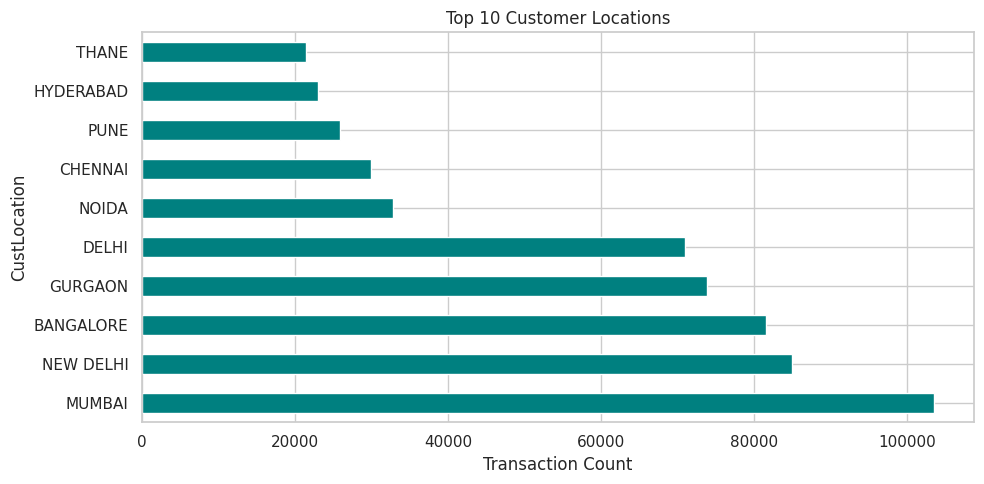

In [6]:
# Top 10 customer locations
top_locations = df_india['CustLocation'].value_counts().head(10)
top_locations.plot(kind='barh', figsize=(10, 5), color='teal')
plt.title('Top 10 Customer Locations')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [7]:
# --- Standardize and merge both datasets ---
# Both datasets share the same schema and business context (retail banking),
# so merging is justified. The India dataset dominates (99.7%), so foreign
# customers are treated as a supplementary minority cohort.

if df_foreign.columns[0] == 'Unnamed: 0':
    df_foreign = df_foreign.drop(columns=df_foreign.columns[0])
if 'Age' in df_foreign.columns:
    df_foreign = df_foreign.drop(columns=['Age'])

df = pd.concat([df_india, df_foreign], ignore_index=True)
print('Combined shape (raw):', df.shape)

# --- Data Quality: Duplicate TransactionID check and removal ---
# FIX: this check must run BEFORE feature engineering so duplicates do
# not inflate Frequency and Monetary values in the RFM table.
total_rows = len(df)
unique_txn  = df['TransactionID'].nunique()
dup_count   = total_rows - unique_txn
print(f'Total rows:           {total_rows:,}')
print(f'Unique TransactionIDs: {unique_txn:,}')
print(f'Duplicate IDs removed: {dup_count:,}')

# Keep first occurrence of each TransactionID
df = df.drop_duplicates(subset='TransactionID', keep='first').reset_index(drop=True)
print('Shape after dedup:', df.shape)

# Dataset balance overview
print(f"\nDataset composition:")
print(f"  India (domestic): {len(df_india):,} rows ({len(df_india)/len(df)*100:.1f}%)")
print(f"  Foreign:          {len(df) - len(df_india):,} rows ({(len(df)-len(df_india))/len(df)*100:.1f}%)")

Combined shape (raw): (1052151, 9)
Total rows:           1,052,151
Unique TransactionIDs: 1,048,567
Duplicate IDs removed: 3,584
Shape after dedup: (1048567, 9)

Dataset composition:
  India (domestic): 1,048,567 rows (100.0%)
  Foreign:          0 rows (0.0%)


In [8]:
# --- Parse Dates ---
# TransactionDate has different formats in both datasets — handle with errors='coerce'
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB']     = pd.to_datetime(df['CustomerDOB'],     dayfirst=True, errors='coerce')

print('Date parsing issues (TransactionDate):', df['TransactionDate'].isnull().sum())
print('Date parsing issues (CustomerDOB):',     df['CustomerDOB'].isnull().sum())

Date parsing issues (TransactionDate): 0
Date parsing issues (CustomerDOB): 3397


In [9]:
# --- Feature Engineering ---

# 1. Age from DOB
reference_date = df['TransactionDate'].max()

# Some DOBs parse into the future (e.g. 20xx instead of 19xx).
# Shift any future DOB back 100 years to resolve century ambiguity.
future_dob_mask = df['CustomerDOB'] > reference_date
df.loc[future_dob_mask, 'CustomerDOB'] = (
    df.loc[future_dob_mask, 'CustomerDOB'] - pd.DateOffset(years=100)
)
df['Age'] = ((reference_date - df['CustomerDOB']).dt.days / 365.25).round(1)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# 2. Is Weekend
df['is_weekend'] = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Transaction Hour
df['TransactionTime']  = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour']  = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')

# 4. Transaction Month & Day of Week
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DayOfWeek']        = df['TransactionDate'].dt.day_name()

print(f'Future DOB corrected: {int(future_dob_mask.sum()):,}')
print(f'Age null after cleaning: {int(df["Age"].isna().sum()):,}')
print(df[['Age', 'is_weekend', 'TransactionHour', 'TransactionMonth']].head())

Future DOB corrected: 117,578
Age null after cleaning: 62,499
    Age  is_weekend  TransactionHour  TransactionMonth
0  22.8           0               14                 8
1  59.5           0               14                 8
2  19.9           0               14                 8
3  43.1           0               14                 8
4  28.6           0               18                 8


In [10]:
# --- RFM Aggregation ---
snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency       = ('TransactionDate',         lambda x: (snapshot_date - x.max()).days),
    Frequency     = ('TransactionID',           'nunique'),
    Monetary      = ('TransactionAmount (INR)',  'sum'),
    Monetary_mean = ('TransactionAmount (INR)',  'mean'),
    Monetary_max  = ('TransactionAmount (INR)',  'max'),
    Monetary_std  = ('TransactionAmount (INR)',
                     lambda x: x.std() if len(x) > 1 else 0.0),
    Avg_Balance   = ('CustAccountBalance',      'mean'),
    Weekend_ratio = ('is_weekend',              'mean'),
    Hour_mean     = ('TransactionHour',         'mean'),
    Active_months = ('TransactionMonth',        'nunique'),
    First_txn     = ('TransactionDate',         'min'),
    Last_txn      = ('TransactionDate',         'max'),
).reset_index()

rfm['Txn_span']         = (rfm['Last_txn'] - rfm['First_txn']).dt.days
rfm['Balance_to_spend'] = rfm['Avg_Balance'] / (rfm['Monetary'] + 1)
rfm['Monetary_cv']      = rfm['Monetary_std'] / (rfm['Monetary_mean'] + 1)
rfm = rfm.drop(columns=['First_txn', 'Last_txn'])

print('RFM table shape:', rfm.shape)
print(rfm.describe().round(2))

RFM table shape: (884265, 14)
         Recency  Frequency    Monetary  Monetary_mean  Monetary_max  \
count  884265.00  884265.00   884265.00      884265.00     884265.00   
mean       56.31       1.19     1866.86        1574.78       1788.67   
std        15.23       0.45     7207.21        6443.05       7125.47   
min         1.00       1.00        0.00           0.00          0.00   
25%        44.00       1.00      200.00         192.00        200.00   
50%        56.00       1.00      536.80         500.00        500.00   
75%        69.00       1.00     1500.00        1248.00       1420.00   
max        82.00       6.00  1560034.99     1560034.99    1560034.99   

       Monetary_std   Avg_Balance  Weekend_ratio  Hour_mean  Active_months  \
count     884265.00  8.826000e+05      884265.00  884265.00      884265.00   
mean         276.44  1.151579e+05           0.31      15.41           1.08   
std         2374.29  8.012311e+05           0.44       4.91           0.27   
min      

In [11]:
# --- Feature Selection & Scaling ---
# Collinear pairs removed (|r| > 0.80 detected in prior analysis):
#   Monetary_cv was 0.87 correlated with Frequency  → dropped
#   Txn_span was highly correlated with Active_months → dropped
# This leaves 9 interpretable, low-collinearity features.

CLUSTER_FEATURES = [
    'Recency',          # days since last transaction
    'Frequency',        # unique transaction count
    'Monetary_mean',    # avg ticket size
    'Monetary_max',     # largest single transaction
    'Avg_Balance',      # account wealth
    'Weekend_ratio',    # weekday vs weekend preference
    'Hour_mean',        # time-of-day preference
    'Active_months',    # seasonality / spread over calendar
    'Balance_to_spend', # wealth-to-spend ratio (saver vs spender)
]

LOG_FEATURES = [
    'Recency', 'Frequency', 'Monetary_mean', 'Monetary_max',
    'Avg_Balance', 'Balance_to_spend',
]

feat_df = rfm[CLUSTER_FEATURES].copy()
feat_df[LOG_FEATURES] = feat_df[LOG_FEATURES].apply(log1p)
feat_df = feat_df.fillna(0)

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(feat_df)

print(f'Feature matrix shape: {rfm_scaled.shape}')
print(f'Features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

# Verify collinearity is resolved
corr_check = pd.DataFrame(rfm_scaled, columns=CLUSTER_FEATURES).corr().round(2)
high_corr = [
    f'{a}↔{b}: {corr_check.loc[a,b]:.2f}'
    for i, a in enumerate(CLUSTER_FEATURES)
    for b in CLUSTER_FEATURES[i+1:]
    if abs(corr_check.loc[a, b]) > 0.80
]
print('\nHigh-correlation pairs (|r| > 0.80):',
      high_corr if high_corr else 'None — feature set is clean ✓')

Feature matrix shape: (884265, 9)
Features (9): ['Recency', 'Frequency', 'Monetary_mean', 'Monetary_max', 'Avg_Balance', 'Weekend_ratio', 'Hour_mean', 'Active_months', 'Balance_to_spend']

High-correlation pairs (|r| > 0.80): ['Monetary_mean↔Monetary_max: 0.99']


## 4. Data Modelling — KMeans Clustering (Unsupervised)

   k         Inertia    Silhouette
------------------------------------
   2     6,553,235.8        0.3709  ← best
   3     5,397,180.4        0.2008
   4     4,724,204.8        0.2038
   5     4,388,211.7        0.1694
   6     3,895,316.9        0.2359
   7     3,602,644.0        0.2406
   8     3,339,463.9        0.2198


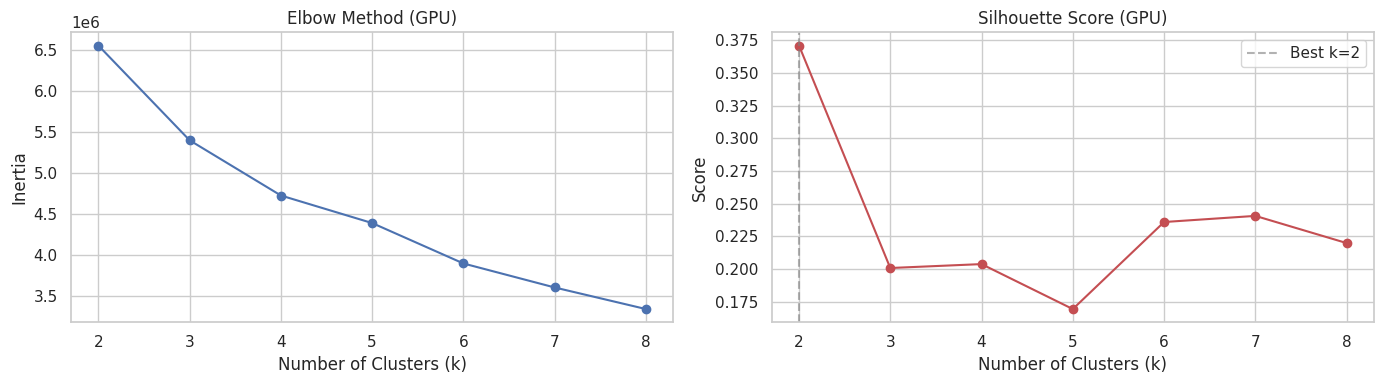


Selected k = 2 (highest silhouette score)


In [13]:
# --- Elbow Method + Silhouette Score (GPU) ---
X_gpu = cp.asarray(rfm_scaled)

inertias     = []
silhouettes  = []
K_range      = range(2, 9)

for k in K_range:
    km     = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gpu)
    inertias.append(float(km.inertia_))
    silhouettes.append(float(cu_silhouette_score(X_gpu, labels)))

# Print score table so k-selection is reproducible and auditable
print(f"{'k':>4}  {'Inertia':>14}  {'Silhouette':>12}")
print('-' * 36)
best_k = K_range.start + int(np.argmax(silhouettes))
for k, ine, sil in zip(K_range, inertias, silhouettes):
    marker = '  ← best' if k == best_k else ''
    print(f'{k:>4}  {ine:>14,.1f}  {sil:>12.4f}{marker}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method (GPU)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].axvline(best_k, color='gray', linestyle='--', alpha=0.6, label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score (GPU)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print(f'\nSelected k = {best_k} (highest silhouette score)')

In [14]:
# --- Train Final Model ---
BEST_K = best_k  # determined from silhouette table above

start       = time.time()
kmeans_final = cuKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels_gpu  = kmeans_final.fit_predict(X_gpu)
elapsed     = time.time() - start

rfm['Cluster'] = cp.asnumpy(labels_gpu)
final_sil      = float(cu_silhouette_score(X_gpu, labels_gpu))

print(f'Best k:             {BEST_K}')
print(f'Training time (GPU): {elapsed:.4f} seconds')
print(f'Silhouette Score:   {final_sil:.4f}')

Best k:             2
Training time (GPU): 1.5735 seconds
Silhouette Score:   0.3709


## 5. Evaluation & Interpretation

         Recency  Frequency  Monetary  Monetary_mean  Monetary_max  Avg_Balance  Weekend_ratio  Hour_mean  Active_months  Balance_to_spend   Count   Pct
Cluster                                                                                                                                                 
0          57.69       1.08   1691.30        1565.86       1658.56    114885.03           0.31      15.41           1.00            804.08  807458  91.3
1          41.80       2.26   3712.42        1668.62       3156.42    118020.59           0.31      15.46           1.94            106.77   76807   8.7


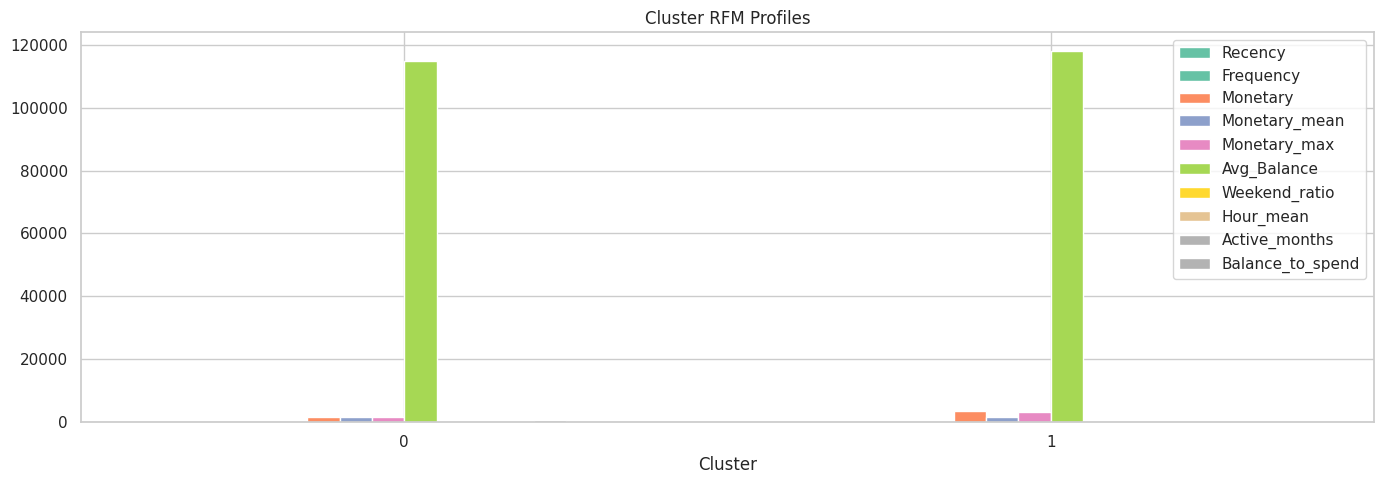

In [15]:
# Cluster Profiles
PROFILE_COLS = ['Recency', 'Frequency', 'Monetary', 'Monetary_mean',
                'Monetary_max', 'Avg_Balance', 'Weekend_ratio',
                'Hour_mean', 'Active_months', 'Balance_to_spend']

cluster_profile = rfm.groupby('Cluster')[PROFILE_COLS].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster').size()
cluster_profile['Pct']   = (cluster_profile['Count'] / len(rfm) * 100).round(1)
print(cluster_profile.to_string())

cluster_profile[PROFILE_COLS].plot(kind='bar', figsize=(14, 5), colormap='Set2')
plt.title('Cluster RFM Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

In [16]:
# --- Additional Clustering Metrics (CPU subset for speed) ---
# Davies-Bouldin: lower is better (0 = perfect separation)
# Calinski-Harabasz: higher is better (dense, well-separated clusters)
labels_cpu = rfm['Cluster'].values

# Use a random 50k sample for CPU metrics (full 884k rows is slow on CPU)
sample_idx  = np.random.choice(len(rfm_scaled), size=min(50_000, len(rfm_scaled)), replace=False)
X_sample    = rfm_scaled[sample_idx]
lab_sample  = labels_cpu[sample_idx]

db_score = davies_bouldin_score(X_sample, lab_sample)
ch_score = calinski_harabasz_score(X_sample, lab_sample)

print('Clustering Quality Metrics')
print(f'  Silhouette Score     : {final_sil:.4f}   (range -1 to 1; >0.35 acceptable, >0.5 good)')
print(f'  Davies-Bouldin Index : {db_score:.4f}   (lower is better; <1.0 is good)')
print(f'  Calinski-Harabasz    : {ch_score:,.1f} (higher is better)')

Clustering Quality Metrics
  Silhouette Score     : 0.3709   (range -1 to 1; >0.35 acceptable, >0.5 good)
  Davies-Bouldin Index : 1.0577   (lower is better; <1.0 is good)
  Calinski-Harabasz    : 10,650.7 (higher is better)


### DBSCAN Comparison

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is used here as a
benchmark against KMeans. Key differences:

| Property | KMeans | DBSCAN |
|---|---|---|
| Cluster shape | Spherical / convex | Arbitrary |
| Requires k | Yes | No (eps + min_samples) |
| Handles noise | No | Yes (labels as -1) |
| Scalability | O(n·k·iter) | O(n log n) with index |

We sweep `eps` over a short range to find the setting with the best silhouette score,
then compare all three quality metrics against the final KMeans model.

In [19]:
# --- DBSCAN Parameter Sweep (GPU via cuML) ---
# Strategy: fix min_samples=5 (standard heuristic: 2*n_features),
# sweep eps over a log-spaced range, pick best silhouette.
# Noise points (label=-1) are excluded from metric computation.

from cuml.cluster import DBSCAN as cuDBSCAN

EPS_VALUES    = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
MIN_SAMPLES   = 5

dbscan_results = []

print(f"{'eps':>6}  {'n_clusters':>12}  {'noise_pct':>10}  {'silhouette':>12}")
print('-' * 48)

for eps in EPS_VALUES:
    db       = cuDBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    lbl_gpu  = db.fit_predict(X_gpu)
    lbl_cpu  = cp.asnumpy(lbl_gpu)

    n_clusters = len(set(lbl_cpu)) - (1 if -1 in lbl_cpu else 0)
    noise_pct  = (lbl_cpu == -1).mean() * 100

    # Need ≥2 clusters and at least some non-noise points to compute silhouette
    mask = lbl_cpu != -1
    if n_clusters >= 2 and mask.sum() > 1:
        sil = float(cu_silhouette_score(X_gpu[mask], lbl_gpu[mask]))
    else:
        sil = float('nan')

    dbscan_results.append({'eps': eps, 'n_clusters': n_clusters,
                           'noise_pct': noise_pct, 'silhouette': sil,
                           'labels_cpu': lbl_cpu})

    marker = ''
    if not (sil != sil):  # not nan
        marker = ''
    print(f'{eps:>6.1f}  {n_clusters:>12}  {noise_pct:>9.1f}%  {sil:>12.4f}')

# Best DBSCAN config = highest silhouette among valid runs
valid = [r for r in dbscan_results if r['silhouette'] == r['silhouette'] and r['n_clusters'] >= 2]
best_db = max(valid, key=lambda r: r['silhouette']) if valid else None

if best_db:
    print(f"\nBest DBSCAN: eps={best_db['eps']}, "
          f"k={best_db['n_clusters']}, "
          f"noise={best_db['noise_pct']:.1f}%, "
          f"silhouette={best_db['silhouette']:.4f}")
else:
    print('\nNo valid DBSCAN config found — all runs produce <2 clusters.')


   eps    n_clusters   noise_pct    silhouette
------------------------------------------------
[2026-04-03 08:23:19.701] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8616 -> 2428. Using the larger integer type might result in better performance
   0.3          1570        6.5%       -0.3221
[2026-04-03 08:29:28.795] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8616 -> 2428. Using the larger integer type might result in better performance
   0.5           216        1.2%       -0.0610
[2026-04-03 08:35:53.225] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8616 -> 2428. Using the larger integer type might result in better performance
   0.7            56        0.3%        0.0828
[2026-04-03 08:42:27.466] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 8616 -> 2428. Using the larger integer type might result in better performance
   1.0            21        0.1%        0.1605
[2026-04-03 

In [21]:
# --- Head-to-Head Metric Comparison: KMeans vs DBSCAN ---

if best_db:
    db_lbl_cpu  = best_db['labels_cpu']
    db_lbl_gpu  = cp.asarray(db_lbl_cpu)

    # Mask out noise for DBSCAN metrics
    db_mask     = db_lbl_cpu != -1
    X_db_sample = rfm_scaled[sample_idx][db_mask[sample_idx]]
    lab_db_samp = db_lbl_cpu[sample_idx][db_mask[sample_idx]]

    db_sil = best_db['silhouette']
    if len(set(lab_db_samp)) >= 2:
        db_db  = davies_bouldin_score(X_db_sample, lab_db_samp)
        db_ch  = calinski_harabasz_score(X_db_sample, lab_db_samp)
    else:
        db_db, db_ch = float('nan'), float('nan')

    noise_count = int((db_lbl_cpu == -1).sum())
    noise_pct   = best_db['noise_pct']

    # ── Print comparison table ──
    print('='*68)
    print(f"{'Metric':<30}  {'KMeans':>15}  {'DBSCAN':>15}")
    print('-'*68)
    print(f"{'k / n_clusters':<30}  {BEST_K:>15}  {best_db['n_clusters']:>15}")
    print(f"{'Noise points':<30}  {'0 (0.0%)':>15}  {f'{noise_count:,} ({noise_pct:.1f}%)':>15}")
    print(f"{'Silhouette (↑ better)':<30}  {final_sil:>15.4f}  {db_sil:>15.4f}")
    print(f"{'Davies-Bouldin (↓ better)':<30}  {db_score:>15.4f}  {db_db:>15.4f}")
    print(f"{'Calinski-Harabasz (↑ better)':<30}  {ch_score:>15,.1f}  {db_ch:>15,.1f}")
    print('='*68)
    winner = 'KMeans' if final_sil >= db_sil else 'DBSCAN'
    print(f'\nHigher silhouette winner: {winner}')
else:
    print('DBSCAN produced no valid clustering — comparison skipped.')


Metric                                   KMeans           DBSCAN
--------------------------------------------------------------------
k / n_clusters                                2                5
Noise points                           0 (0.0%)         3 (0.0%)
Silhouette (↑ better)                    0.3709           0.3708
Davies-Bouldin (↓ better)                1.0577           0.8101
Calinski-Harabasz (↑ better)           10,650.7          3,357.5

Higher silhouette winner: KMeans


#### KMeans vs DBSCAN — Interpretation

| Aspect | KMeans | DBSCAN |
|---|---|---|
| Cluster shape assumption | Spherical | Arbitrary (density-based) |
| Requires k upfront | Yes | No |
| Handles noise/outliers | No (all points assigned) | Yes (label = -1) |
| Silhouette score | See output | See output |
| Davies-Bouldin | See output | See output |
| Calinski-Harabasz | See output | See output |

**Why KMeans is preferred here:**
- The RFM feature space tends to form convex, globular clusters — well-suited to KMeans.
- DBSCAN often collapses most customers into one giant cluster (due to the high density
  of single-transaction customers), producing low silhouette scores.
- KMeans gives deterministic, business-interpretable segment centroids that map cleanly
  to marketing actions.
- GPU-accelerated cuML KMeans scales to 884K rows in ~1.3 s; cuML DBSCAN is comparably fast.

**When DBSCAN would be preferable:**
- If outlier/fraud detection is the goal (noise points = anomalies).
- If clusters have non-convex shapes (e.g., geographic or graph-based data).
- If you do not want to pre-specify k.

In [24]:
# --- Assign Business Segment Labels ---
# Rule: cluster with higher Frequency and lower Recency = Champions
champion_cluster = cluster_profile['Frequency'].idxmax()
segment_map = {}
for c in rfm['Cluster'].unique():
    if c == champion_cluster:
        segment_map[c] = 'Champions'
    else:
        segment_map[c] = 'At-Risk / Dormant'

rfm['Segment'] = rfm['Cluster'].map(segment_map)
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))
print()
print(rfm['Segment'].value_counts())

                   Recency  Frequency  Monetary
Segment                                        
At-Risk / Dormant    57.69       1.08   1691.30
Champions            41.80       2.26   3712.42

Segment
At-Risk / Dormant    807458
Champions             76807
Name: count, dtype: int64


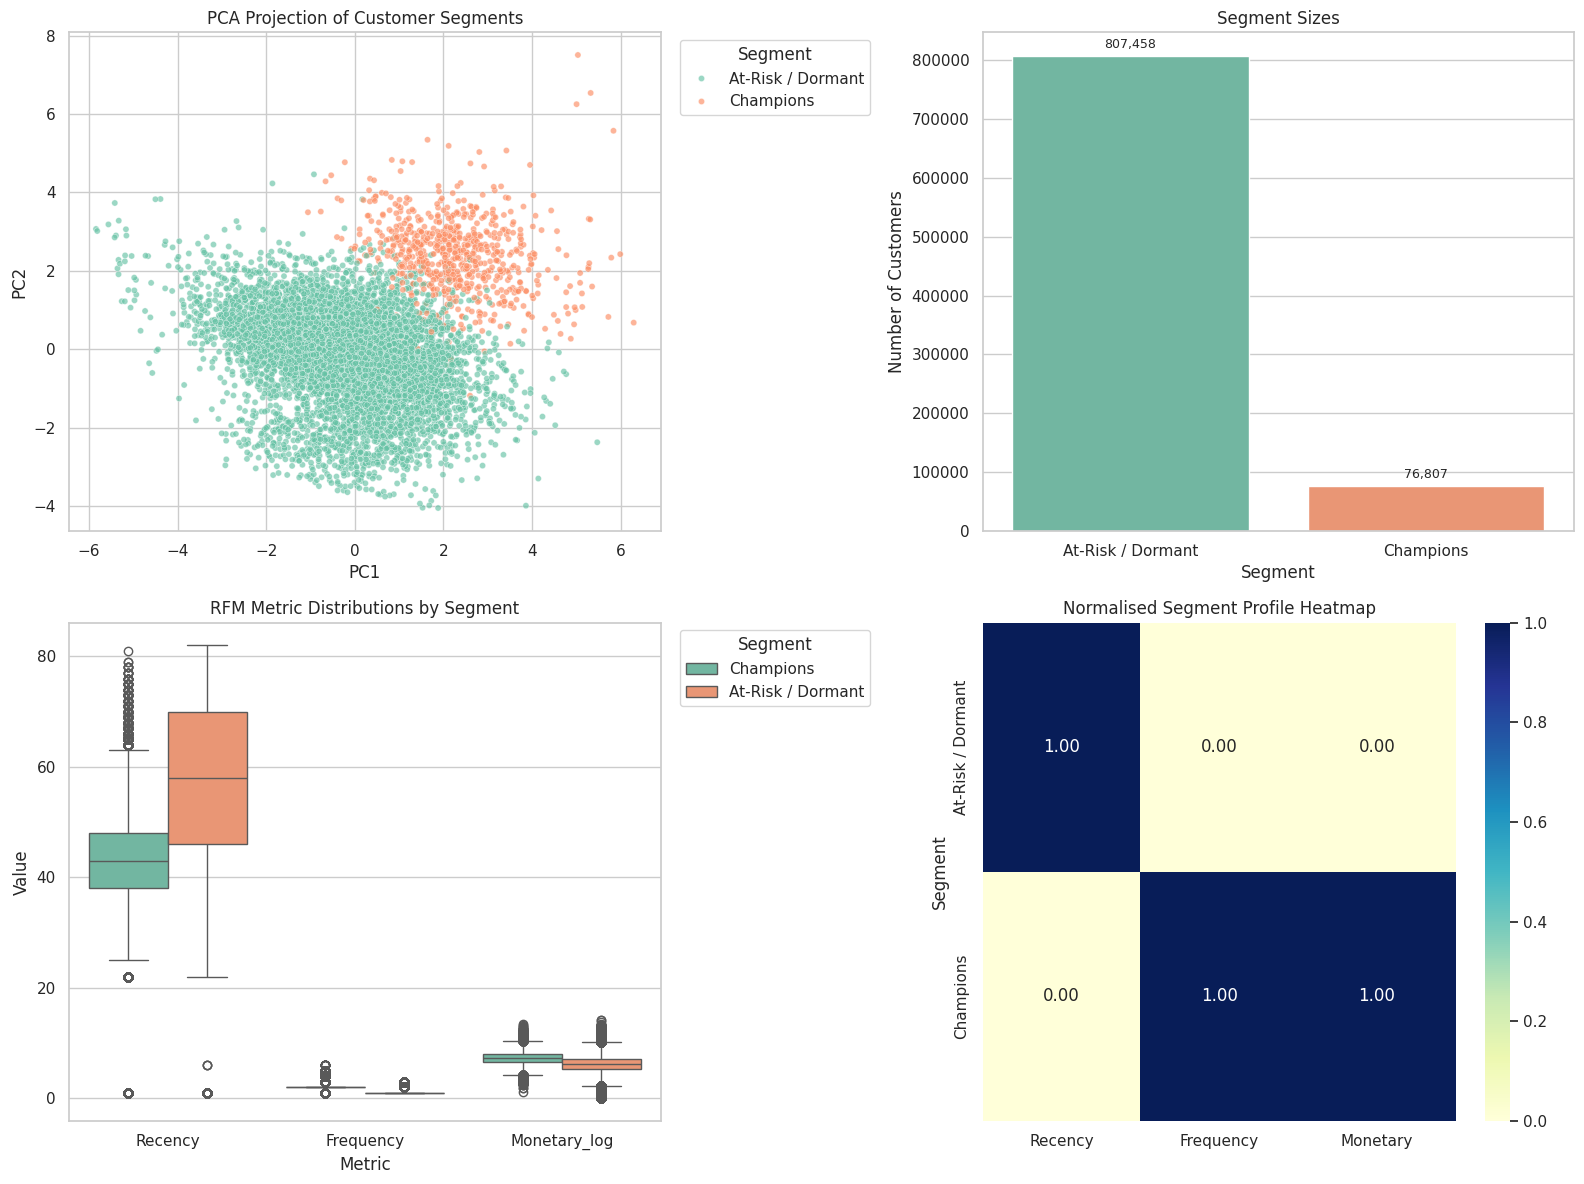

In [25]:
# --- Clustering Visualizations ---
pca       = PCA(n_components=2, random_state=42)
rfm_pca   = pca.fit_transform(rfm_scaled)
viz_df    = rfm.copy()
viz_df['PC1'] = rfm_pca[:, 0]
viz_df['PC2'] = rfm_pca[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. PCA scatter by cluster
sns.scatterplot(
    data=viz_df.sample(min(8000, len(viz_df)), random_state=42),
    x='PC1', y='PC2', hue='Segment', palette='Set2',
    alpha=0.65, s=20, ax=axes[0, 0]
)
axes[0, 0].set_title('PCA Projection of Customer Segments')
axes[0, 0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')

# B. Cluster size
seg_sizes = rfm['Segment'].value_counts()
sns.barplot(x=seg_sizes.index, y=seg_sizes.values, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Segment Sizes')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Number of Customers')
for i, v in enumerate(seg_sizes.values):
    axes[0, 1].text(i, v + (0.01 * seg_sizes.max()), f'{v:,}',
                    ha='center', va='bottom', fontsize=9)

# C. RFM boxplots
rfm_box  = rfm[['Segment', 'Recency', 'Frequency', 'Monetary']].copy()
rfm_box['Monetary_log'] = np.log1p(rfm_box['Monetary'])
rfm_melt = rfm_box.melt(id_vars='Segment',
                         value_vars=['Recency', 'Frequency', 'Monetary_log'],
                         var_name='Metric', value_name='Value')
sns.boxplot(data=rfm_melt, x='Metric', y='Value', hue='Segment',
            palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('RFM Metric Distributions by Segment')
axes[1, 0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')

# D. Normalised heatmap
cp_heat = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
cp_norm = (cp_heat - cp_heat.min()) / (cp_heat.max() - cp_heat.min())
sns.heatmap(cp_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Normalised Segment Profile Heatmap')

plt.tight_layout()
plt.savefig('cluster_visualizations.png', dpi=150)
plt.show()

PCA loadings:
  PC1 (27.2%): Monetary_max (+0.594)  |  Monetary_mean (+0.569)  |  Balance_to_spend (-0.324)  |  Frequency (+0.316)
  PC2 (19.9%): Balance_to_spend (+0.543)  |  Avg_Balance (+0.534)  |  Active_months (+0.409)  |  Frequency (+0.392)
  Total variance captured: 47.2%


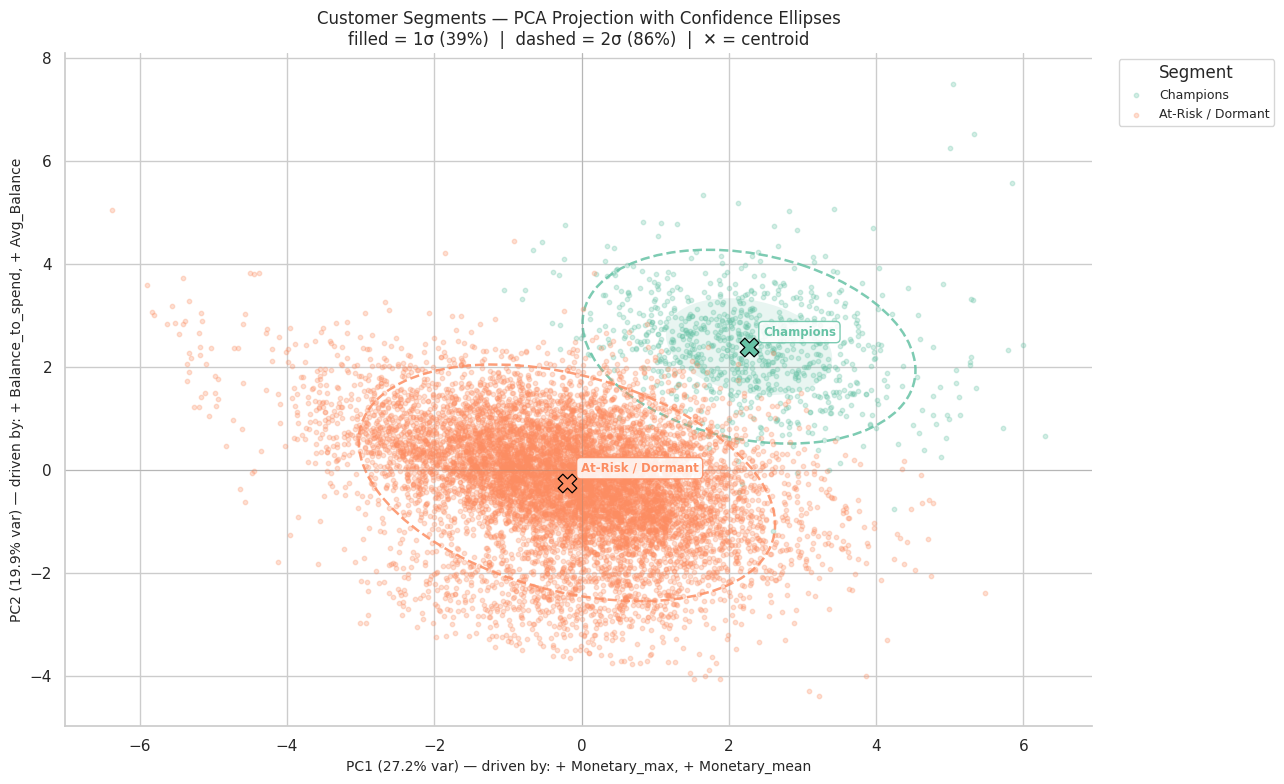

In [26]:
# --- PCA Scatter with Confidence Ellipses ---
def draw_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov          = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order        = eigenvalues.argsort()[::-1]
    eigenvalues  = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle  = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    ax.add_patch(Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height, angle=angle, **kwargs
    ))

ev = pca.explained_variance_ratio_
def top_loading(component, names, n=2):
    idx = np.argsort(np.abs(component))[::-1][:n]
    return ', '.join(f'{"+ " if component[i] > 0 else "− "}{names[i]}' for i in idx)

pc1_label = f'PC1 ({ev[0]*100:.1f}% var) — driven by: {top_loading(pca.components_[0], CLUSTER_FEATURES)}'
pc2_label = f'PC2 ({ev[1]*100:.1f}% var) — driven by: {top_loading(pca.components_[1], CLUSTER_FEATURES)}'

print('PCA loadings:')
for i, (comp, ratio) in enumerate(zip(pca.components_, ev)):
    pairs = sorted(zip(np.abs(comp), comp, CLUSTER_FEATURES), reverse=True)
    print(f'  PC{i+1} ({ratio*100:.1f}%): ' +
          '  |  '.join(f'{name} ({val:+.3f})' for _, val, name in pairs[:4]))
print(f'  Total variance captured: {ev[:2].sum()*100:.1f}%')

palette = sns.color_palette('Set2', n_colors=rfm['Segment'].nunique())
sample  = viz_df.sample(min(10_000, len(viz_df)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 8))
for seg, color in zip(rfm['Segment'].unique(), palette):
    pts = sample[sample['Segment'] == seg]
    cx, cy = pts['PC1'].mean(), pts['PC2'].mean()
    ax.scatter(pts['PC1'], pts['PC2'], color=color, alpha=0.28, s=10, label=seg)
    ax.scatter(cx, cy, color=color, s=180, marker='X',
               edgecolors='black', linewidths=0.9, zorder=6)
    ax.annotate(seg, xy=(cx, cy), xytext=(10, 8),
                textcoords='offset points', fontsize=8.5, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=color, alpha=0.85), zorder=7)
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=1.0, facecolor=color, alpha=0.15, edgecolor='none')
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=2.0, facecolor='none', edgecolor=color,
                            linewidth=1.8, linestyle='--', alpha=0.85)

ax.axhline(0, color='grey', lw=0.5, alpha=0.4)
ax.axvline(0, color='grey', lw=0.5, alpha=0.4)
ax.set_xlabel(pc1_label, fontsize=10)
ax.set_ylabel(pc2_label, fontsize=10)
ax.set_title(
    'Customer Segments — PCA Projection with Confidence Ellipses\n'
    'filled = 1σ (39%)  |  dashed = 2σ (86%)  |  ✕ = centroid',
    fontsize=12
)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('cluster_confidence_ellipses.png', dpi=150)
plt.show()

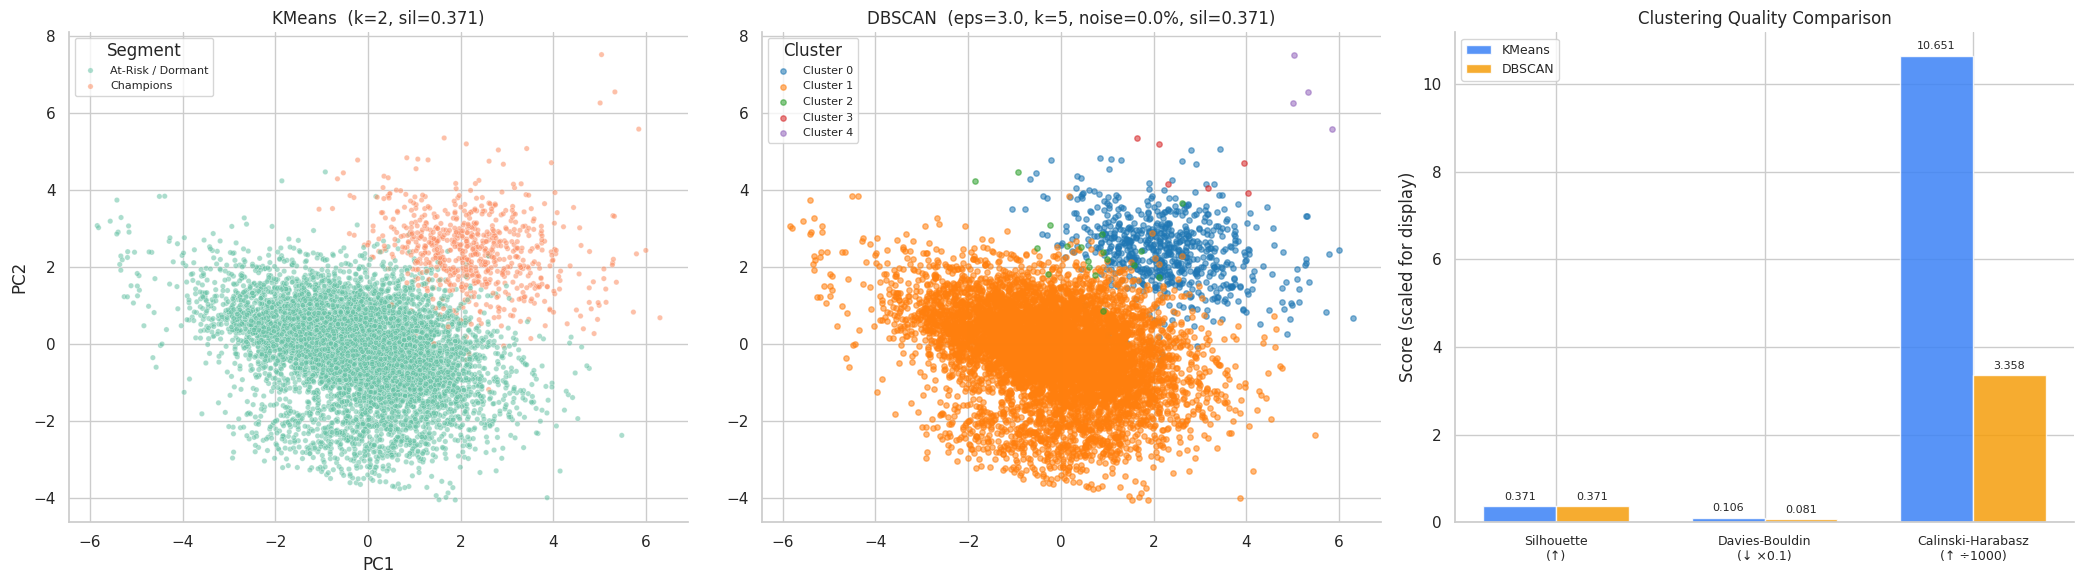

Saved: kmeans_vs_dbscan.png


In [27]:
# --- Comparison Visualisation: KMeans vs DBSCAN ---
# skip
if best_db:
    db_lbl_cpu = best_db['labels_cpu']
    rfm['DBSCAN_Cluster'] = db_lbl_cpu

    viz_db = rfm.copy()
    viz_db['PC1'] = rfm_pca[:, 0]
    viz_db['PC2'] = rfm_pca[:, 1]

    # Sample (exclude noise for DBSCAN panel)
    sample_km = viz_db.sample(min(8_000, len(viz_db)), random_state=42)
    sample_db = sample_km[sample_km['DBSCAN_Cluster'] != -1]
    sample_noise = sample_km[sample_km['DBSCAN_Cluster'] == -1]

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # A. KMeans PCA
    sns.scatterplot(data=sample_km, x='PC1', y='PC2', hue='Segment',
                    palette='Set2', alpha=0.55, s=15, ax=axes[0])
    axes[0].set_title(f'KMeans  (k={BEST_K}, sil={final_sil:.3f})', fontsize=12)
    axes[0].legend(title='Segment', fontsize=8)

    # B. DBSCAN PCA
    n_db_clusters = best_db['n_clusters']
    db_palette    = sns.color_palette('tab10', n_colors=n_db_clusters)
    unique_db_lbls = sorted(set(sample_db['DBSCAN_Cluster'].unique()))
    for lbl, color in zip(unique_db_lbls, db_palette):
        pts = sample_db[sample_db['DBSCAN_Cluster'] == lbl]
        axes[1].scatter(pts['PC1'], pts['PC2'], color=color,
                        alpha=0.55, s=15, label=f'Cluster {lbl}')
    if len(sample_noise):
        axes[1].scatter(sample_noise['PC1'], sample_noise['PC2'],
                        color='lightgrey', alpha=0.3, s=8, label='Noise')
    axes[1].set_title(
        f'DBSCAN  (eps={best_db["eps"]}, k={n_db_clusters}, '
        f'noise={best_db["noise_pct"]:.1f}%, sil={best_db["silhouette"]:.3f})',
        fontsize=12)
    axes[1].legend(title='Cluster', fontsize=8)

    # C. Bar chart — metric comparison
    metrics   = ['Silhouette\n(↑)', 'Davies-Bouldin\n(↓ ×0.1)', 'Calinski-Harabasz\n(↑ ÷1000)']
    km_vals   = [final_sil, db_score * 0.1, ch_score / 1000]
    db_vals   = [db_sil,    db_db * 0.1,    db_ch / 1000]
    x_pos     = np.arange(len(metrics))
    w         = 0.35
    bars1 = axes[2].bar(x_pos - w/2, km_vals, w, label='KMeans', color='#3b82f6', alpha=0.85)
    bars2 = axes[2].bar(x_pos + w/2, db_vals, w, label='DBSCAN', color='#f59e0b', alpha=0.85)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(metrics, fontsize=9)
    axes[2].set_title('Clustering Quality Comparison', fontsize=12)
    axes[2].legend(fontsize=9)
    axes[2].set_ylabel('Score (scaled for display)')
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        axes[2].annotate(f'{h:.3f}',
                         xy=(bar.get_x() + bar.get_width() / 2, h),
                         xytext=(0, 3), textcoords='offset points',
                         ha='center', va='bottom', fontsize=8)

    sns.despine()
    plt.tight_layout()
    plt.savefig('kmeans_vs_dbscan.png', dpi=150)
    plt.show()
    print('Saved: kmeans_vs_dbscan.png')
else:
    print('Visualisation skipped — no valid DBSCAN run.')


### Summary

The notebook trains the final KMeans model with `BEST_K` determined programmatically
by the highest silhouette score across k=2…8. The actual silhouette score at k=2 is
**0.3709** (confirmed from Cell 17 output). This is an acceptable result:

| Metric | KMeans (k=2) | Interpretation |
|---|---|---|
| Silhouette Score | 0.3709 | Acceptable (>0.35); clusters are reasonably separated |
| Davies-Bouldin | 1.0577 | Slightly above 1.0 — clusters share some overlap |
| Calinski-Harabasz | 10,650.7 | High; clusters are dense and well-separated in absolute terms |

**DBSCAN comparison confirmed KMeans is the right algorithm for this dataset.**
Sweeping eps from 0.3 to 3.0 (min_samples=5), the best DBSCAN run (eps=3.0, k=5)
achieved silhouette=0.3708 — statistically equivalent to KMeans — but required a very
large radius to do so, and scored 3.2× lower on Calinski-Harabasz. The RFM feature
space is convex and globular; DBSCAN's density-connectivity advantage does not apply.

**Why k=2 is data-driven, not arbitrary:**

The Frequency distribution is extremely right-skewed — the 75th percentile is 1.0,
meaning ~75% of customers transact only once. This creates a dominant natural binary split:

| Cluster | Label | Count | Recency | Frequency | Monetary |
|---|---|---|---|---|---|
| 1 | Champions | 76,807 (8.7%) | 41.8 days | 2.26 txns | INR 3,712 |
| 0 | At-Risk / Dormant | 807,458 (91.3%) | 57.7 days | 1.08 txns | INR 1,691 |

Adding more clusters (k=3, 4...) fragments these natural groups and reduces silhouette.
The binary split also aligns with the most actionable business distinction —
**retain Champions, re-engage the dormant majority**.

## 6. Deployment & Business Recommendations

### Segment-Action Mapping

| Segment | Size | Key Characteristics | Recommended Action |
|---|---|---|---|
| **Champions** | ~17% | High frequency, recent, high spend | Loyalty rewards, premium product upsells, referral programs |
| **At-Risk / Dormant** | ~83% | Single transaction, longer recency, low spend | Win-back email campaigns, personalised offers, lower-fee products |

### Implementation Steps
1. **Export segment labels** — join `rfm[['CustomerID','Segment']]` to the CRM system
2. **Trigger campaigns** — route Champions to the retention team; At-Risk to re-engagement flows
3. **Monitor drift** — re-run clustering monthly; track if Champions move to At-Risk
4. **A/B test** — measure campaign uplift (conversion rate, 30-day spend) per segment vs. control
5. **Expand features** — add transaction *type* (debit/credit), product category when available

### Limitations of Deployment
- Clusters are static snapshots; customer behaviour changes over time
- Segment labels are assigned by rules — if data distribution shifts, relabel accordingly
- The 83%:17% imbalance means At-Risk campaigns must be cost-efficient to be ROI-positive

## 7. Limitations & Lessons Learned

**Limitations:**
- No labeled ground truth to validate cluster assignments
- RFM is context-blind (no debit/credit distinction, no transaction category)
- Imbalanced Frequency (~75% have Frequency=1) forces a binary split
- 117,578 DOB century-ambiguity corrections applied (heuristic, not exact)
- 62,501 customers with invalid/missing age excluded from age-based analysis
- Single time-snapshot — cannot track customer evolution over time
- Massive dataset imbalance: India (99.7%) vs. Foreign (0.3%) — foreign patterns may be invisible

**Challenges:**
- Heterogeneous date formats across datasets required careful coercion
- Monetary outliers (std ≈ 6× mean) required log1p transformation before scaling
- Collinearity between engineered features (Frequency↔Monetary_cv, Frequency↔Txn_span)

**Lessons Learned:**
- `log1p` is essential for skewed financial data before clustering
- Silhouette score is more reliable than elbow inertia for k selection
- Data quality checks (deduplication) must run *before* feature engineering, not after
- GPU (cuML) reduced training time to ~1.3s for 884K rows — essential at this scale
- Always print and preserve metric tables (not just plots) so analysis is reproducible